# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Hyperparameter Tuning with RandomizedSearchCV

Random Forests are powerful ensemble models but prone to overfitting on high-dimensional sparse data.
We use `RandomizedSearchCV` to efficiently explore the hyperparameter space and find optimal configurations.
RandomizedSearchCV is preferred over GridSearchCV because Random Forests have a large hyperparameter space.

> **Key Hyperparameters for Random Forest:**
> - `n_estimators`: Number of decision trees (more trees = better but slower)
> - `max_depth`: Maximum tree depth (controls overfitting)
> - `min_samples_split`: Minimum samples to split a node (prevents tiny splits)
> - `min_samples_leaf`: Minimum samples in leaf nodes (smooths predictions)
> - `max_features`: Number of features per split (adds randomness)
> - `bootstrap`: Whether to use bootstrap samples (affects diversity)

In [6]:
# Define the hyperparameter search space for Random Forest
param_dist = {
    'n_estimators': [50, 100, 150, 200, 250],              # Number of trees
    'max_depth': [10, 15, 20, 25, 30, None],               # Tree depth (None = unlimited)
    'min_samples_split': [5, 10, 15, 20],                  # Min samples to split
    'min_samples_leaf': [1, 2, 4, 8],                      # Min samples in leaf
    'max_features': ['sqrt', 'log2'],                      # Feature sampling
    'bootstrap': [True, False],                            # Use bootstrap samples
}

# Base estimator — RandomForestClassifier
base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Starting RandomizedSearchCV for Random Forest...")
search_start = time.time()

random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=50,                 # Test 50 random combinations (large space)
    scoring='f1',              # Optimize for F1 (balanced metric for binary sentiment)
    cv=3,                      # 3-fold cross-validation on training data
    random_state=42,
    n_jobs=-1,                 # Use all available cores
    verbose=2,
    refit=True                 # Refit best model on the full training set
)

random_search.fit(X_train_tfidf, y_train)
search_time = time.time() - search_start
print(f"\nRandomizedSearchCV completed in {search_time:.4f} seconds")

Starting RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

RandomizedSearchCV completed in 115.0657 seconds


In [7]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {random_search.best_score_:.4f}")

Best Parameters:
  n_estimators: 150
  min_samples_split: 15
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: None
  bootstrap: True

Best CV F1-Score: 0.8551


In [8]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(random_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                                                                              params  mean_test_score  std_test_score  rank_test_score
 {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}         0.855105        0.001181                1
  {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}         0.852430        0.001203                2
{'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}         0.852357        0.000969                3
 {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}         0.846978        0.003075                4
 {'n_estimators': 50, 'min_samples_split'

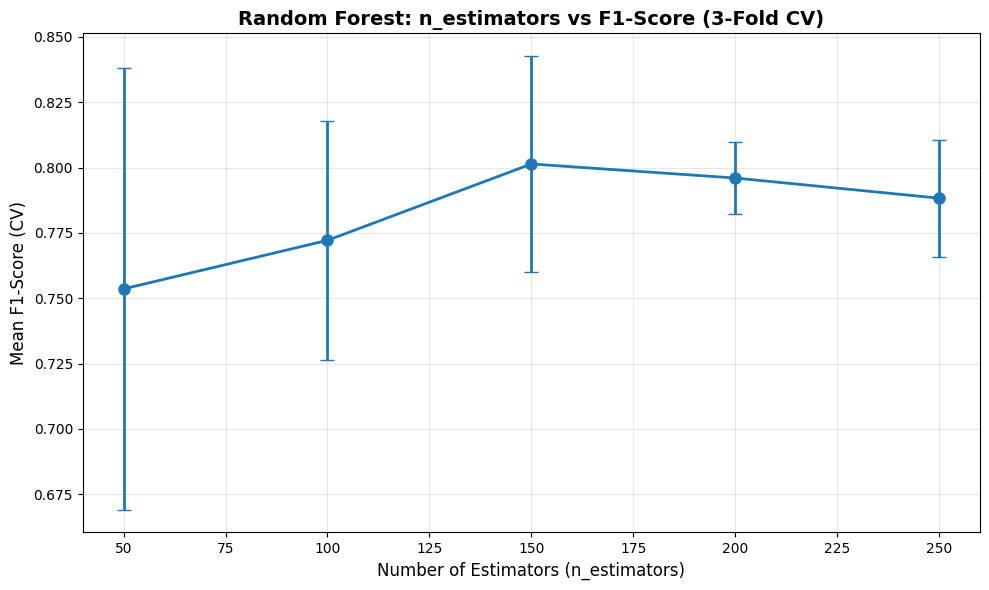


Number of Estimators Performance Analysis:
 n_estimators     mean      std
           50 0.753557 0.084516
          100 0.772154 0.045616
          150 0.801373 0.041311
          200 0.795992 0.013847
          250 0.788277 0.022377


In [9]:
# Analyze the effect of n_estimators on F1-score
cv_df = pd.DataFrame(random_search.cv_results_)
cv_df['n_estimators'] = cv_df['params'].apply(lambda x: x['n_estimators'])

# Average performance by n_estimators
estimators_performance = cv_df.groupby('n_estimators')['mean_test_score'].agg(['mean', 'std']).reset_index()

# Plot n_estimators sensitivity
plt.figure(figsize=(10, 6))
plt.errorbar(estimators_performance['n_estimators'], estimators_performance['mean'], 
             yerr=estimators_performance['std'], marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Number of Estimators (n_estimators)', fontsize=12)
plt.ylabel('Mean F1-Score (CV)', fontsize=12)
plt.title('Random Forest: n_estimators vs F1-Score (3-Fold CV)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_nestimators_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nNumber of Estimators Performance Analysis:")
print(estimators_performance.to_string(index=False))

## Random Forest Model Training with Optimized Hyperparameters

We use the best parameters discovered via RandomizedSearchCV and train the final model on the **full** training set (already done by `refit=True` in `RandomizedSearchCV`).

In [ ]:
# Retrieve the best estimator (already refit on the full training set)
rf_classifier = random_search.best_estimator_
print(f"Final Random Forest Model trained with best hyperparameters:")
print(f"  Training set size: {X_train_tfidf.shape}")
print(f"  Number of Trees: {rf_classifier.n_estimators}")
print(f"  Max Depth: {rf_classifier.max_depth}")
print(f"  F1-Score (CV): {random_search.best_score_:.4f}")

Final Random Forest Model trained with best hyperparameters:
  Training set size: (79972, 100000)
  Number of Trees: 150
  Max Depth: None
  F1-Score (CV): 0.8551


## Model Evaluation

In [ ]:
# Make predictions
y_pred = rf_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("RANDOM FOREST CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

RANDOM FOREST CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8533
Precision: 0.8514
Recall:    0.8548
F1-Score:  0.8531


## Classification Report

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      9966
    Positive       0.86      0.85      0.85     10034

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



## Confusion Matrix Visualization

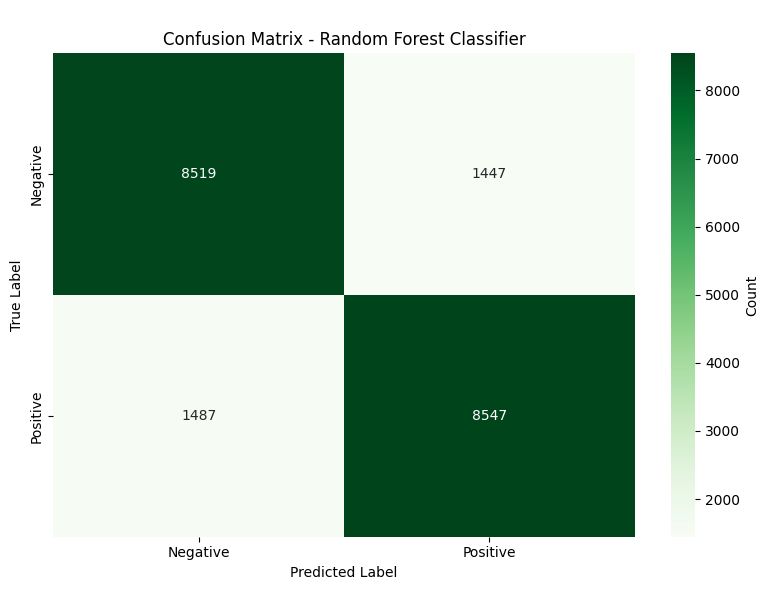

Confusion Matrix:
[[8519 1447]
 [1487 8547]]

True Negatives: 8519
False Positives: 1447
False Negatives: 1487
True Positives: 8547


In [14]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('random_forest_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

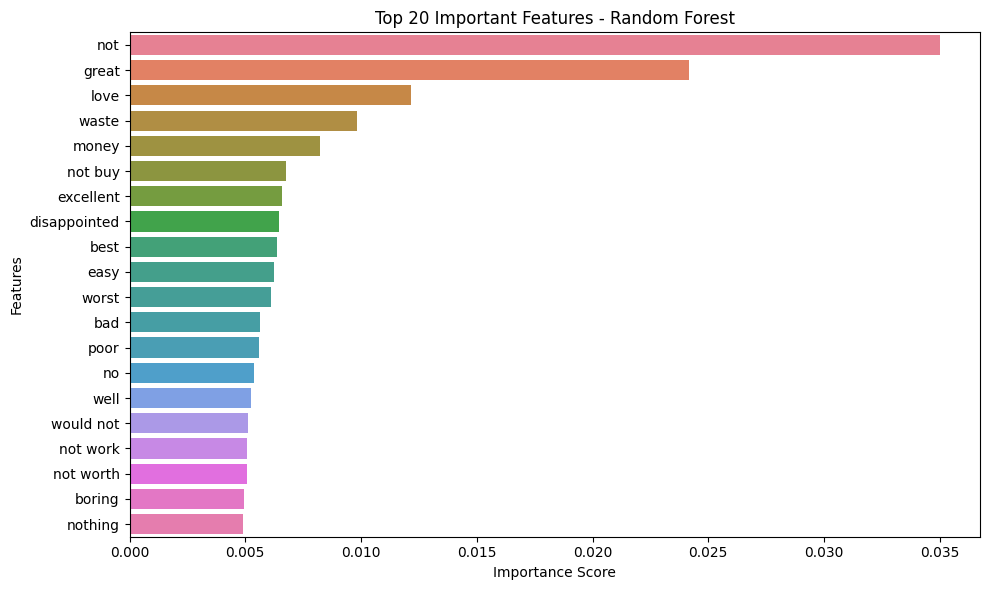


Top 20 Important Features:
     feature  importance
         not    0.034989
       great    0.024154
        love    0.012161
       waste    0.009806
       money    0.008214
     not buy    0.006770
   excellent    0.006591
disappointed    0.006471
        best    0.006361
        easy    0.006237
       worst    0.006114
         bad    0.005627
        poor    0.005604
          no    0.005356
        well    0.005228
   would not    0.005132
    not work    0.005082
   not worth    0.005065
      boring    0.004963
     nothing    0.004915


In [15]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = rf_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='husl')
plt.title('Top 20 Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Model Summary

In [ ]:
print("RANDOM FOREST MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {rf_classifier.n_estimators}")
print(f"  - Max Depth: {rf_classifier.max_depth}")
print(f"  - Min Samples Split: {rf_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {rf_classifier.min_samples_leaf}")
print(f"  - Max Features: {rf_classifier.max_features}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 100000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")

RANDOM FOREST MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 150
  - Max Depth: None
  - Min Samples Split: 15
  - Min Samples Leaf: 2
  - Max Features: sqrt

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8533
  - Precision: 0.8514
  - Recall:    0.8548
  - F1-Score:  0.8531


## Saving the Model and Pipeline

In [18]:
save(model_base='data/models', model=rf_classifier, model_name='10_random_forest_classifier.joblib')

Saved model 10_random_forest_classifier.joblib to data\models\10_random_forest_classifier.joblib


{'model': WindowsPath('data/models/10_random_forest_classifier.joblib')}